# Energy Regime Similarity Search System
## Exploratory Data Analysis 

This notebook performs **Exploratory Data Analysis (EDA)** and on electricity market data.

The dataset comes from the Open Power System Data platform and contains **time-series electricity measurements** such as:

- timestamp (time of observation)
- load (electricity demand)
- price (electricity market price)

The goal of this analysis is to:

• understand the statistical properties of the dataset  
• analyze temporal patterns in electricity demand and price  
• clean and preprocess the data  
• create useful features for machine learning models  

These engineered features will later be used to train a **Hidden Markov Model (HMM)** for detecting hidden operational regimes in energy systems.

In [9]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# Load Dataset

We load the electricity dataset using the Pandas library.

The dataset is stored as a CSV file containing historical electricity measurements collected at regular intervals.

In [10]:
# Load the dataset

df = pd.read_csv("../data/time_series_60min_singleindex.csv")

df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [11]:
df.shape

(50401, 300)

In [12]:
df.columns

Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='str', length=300)

In [13]:
df = df[[
    "utc_timestamp",
    "DE_load_actual_entsoe_transparency",
    "DE_solar_generation_actual",
    "DE_wind_generation_actual"
]]

df = df.rename(columns={
    "utc_timestamp": "timestamp",
    "DE_load_actual_entsoe_transparency": "load",
    "DE_solar_generation_actual": "solar",
    "DE_wind_generation_actual": "wind"
})

In [14]:
df.isnull().sum()

timestamp      0
load           1
solar        104
wind          75
dtype: int64

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [16]:
df = df.sort_values("timestamp")

In [17]:
df = df.set_index("timestamp")

In [18]:
df.head()

,load,solar,wind
timestamp,,,
2014-12-31 23:00:00+00:00,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,41151.0,NaN,8852.0
2015-01-01 01:00:00+00:00,40135.0,NaN,9054.0
2015-01-01 02:00:00+00:00,39106.0,NaN,9070.0
2015-01-01 03:00:00+00:00,38765.0,NaN,9163.0


In [19]:
df = df.ffill()
df = df.dropna()
df.isnull().sum()

load     0
solar    0
wind     0
dtype: int64

In [20]:
df.describe()

,load,solar,wind
count,50393.000000,50393.000000,50393.000000
mean,55494.673189,4557.344472,11554.193142
std,10014.374825,6936.511726,9073.923376
min,31307.000000,0.000000,135.000000
25%,47107.000000,0.000000,4502.000000
50%,55093.000000,164.000000,9017.000000
75%,64310.000000,7315.000000,16122.000000
max,77549.000000,32947.000000,46064.000000


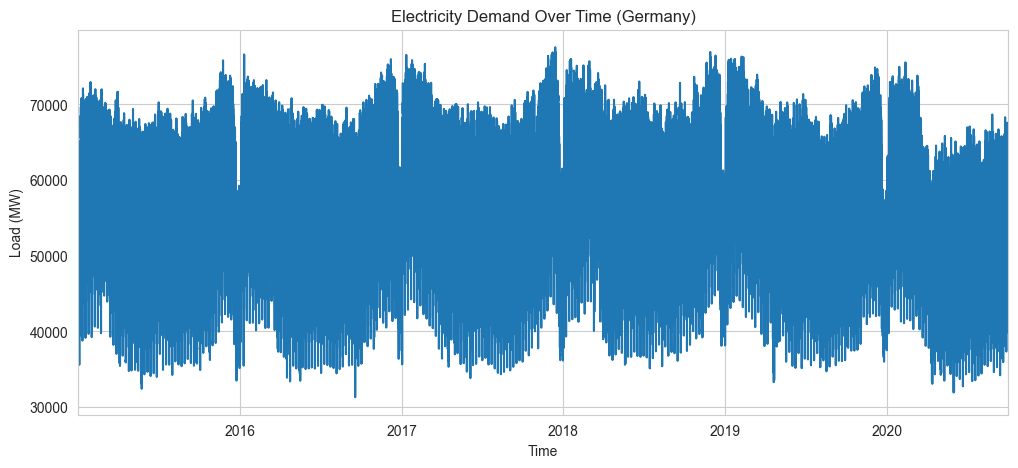

In [21]:
plt.figure(figsize=(12,5))

df["load"].plot()

plt.title("Electricity Demand Over Time (Germany)")
plt.xlabel("Time")
plt.ylabel("Load (MW)")

plt.show()

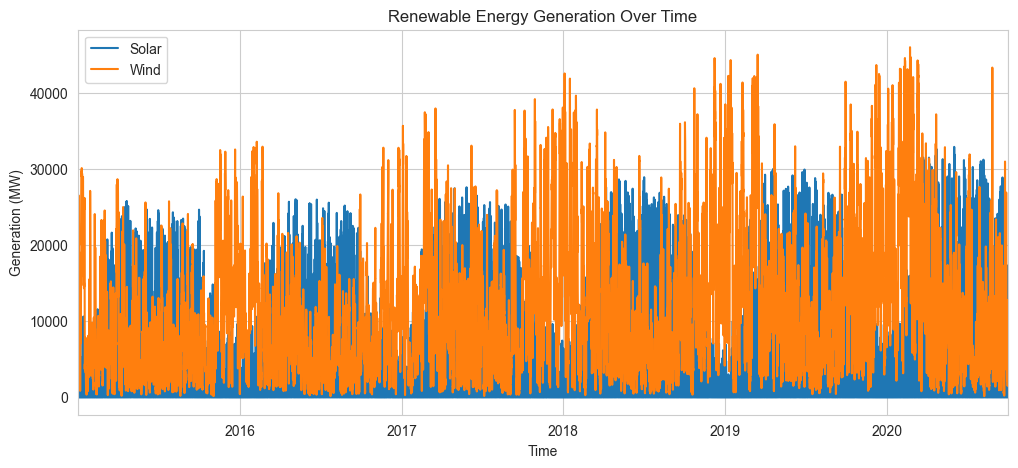

In [22]:
plt.figure(figsize=(12,5))

df["solar"].plot(label="Solar")
df["wind"].plot(label="Wind")

plt.title("Renewable Energy Generation Over Time")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")
plt.legend()

plt.show()

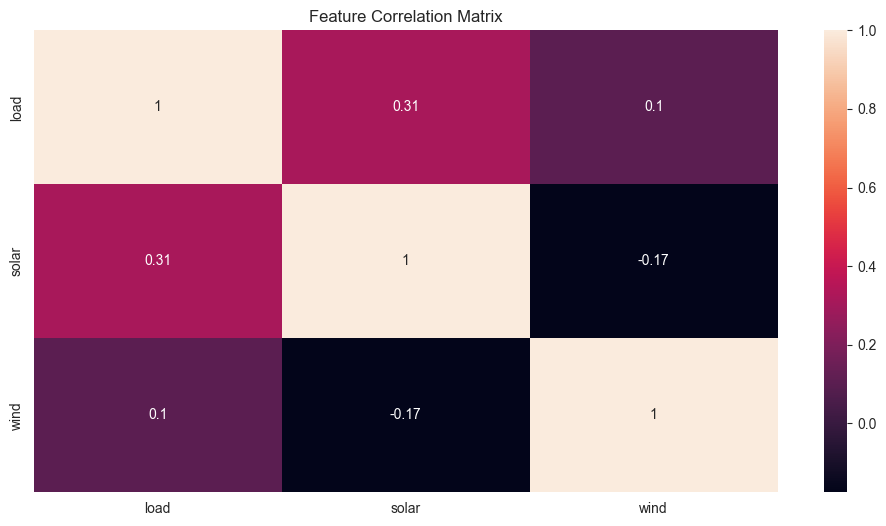

In [23]:
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

## Feature Engineering

Feature engineering is the process of transforming raw data into meaningful input variables that improve the performance of machine learning models. 

In this project, new time-based and energy-related features are created from the original dataset to capture patterns in electricity demand and renewable generation. These engineered features help the model identify different energy regimes such as high demand periods, renewable-heavy generation periods, and normal operating conditions.

The following types of features will be created:
- Time-based features (hour, day of week, month)
- Energy relationship features (renewable generation ratios)
- Change-based features (load variation over time)
- Rolling statistics to capture short-term trends

In [24]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month

df["renewable_generation"] = df["solar"] + df["wind"]

df["renewable_ratio"] = df["renewable_generation"] / df["load"]

df["load_change"] = df["load"].diff()

df["renewable_change"] = df["renewable_generation"].diff()

df["rolling_load_24h"] = df["load"].rolling(window=24).mean()

df.head()

,load,solar,wind,hour,day_of_week,month,renewable_generation,renewable_ratio,load_change,renewable_change,rolling_load_24h
timestamp,,,,,,,,,,,
2015-01-01 07:00:00+00:00,41133.0,71.0,10208.0,7,3,1,10279.0,0.249897,NaN,NaN,NaN
2015-01-01 08:00:00+00:00,42963.0,773.0,10029.0,8,3,1,10802.0,0.251426,1830.0,523.0,NaN
2015-01-01 09:00:00+00:00,45088.0,2117.0,10550.0,9,3,1,12667.0,0.280939,2125.0,1865.0,NaN
2015-01-01 10:00:00+00:00,47013.0,3364.0,11390.0,10,3,1,14754.0,0.313828,1925.0,2087.0,NaN
2015-01-01 11:00:00+00:00,48159.0,4198.0,12103.0,11,3,1,16301.0,0.338483,1146.0,1547.0,NaN


In [25]:
df = df.dropna()
df.isnull().sum()

load                    0
solar                   0
wind                    0
hour                    0
day_of_week             0
month                   0
renewable_generation    0
renewable_ratio         0
load_change             0
renewable_change        0
rolling_load_24h        0
dtype: int64

## Feature Scaling

Before training the model, the features are scaled to ensure all variables are on a similar numerical range. Since some variables (like load) have much larger values than others (like ratios or time indicators), scaling prevents any single feature from dominating the model. StandardScaler from scikit-learn is used to standardize the data before training the Hidden Markov Model.

In [26]:
features = [
    "load",
    "solar",
    "wind",
    "hour",
    "day_of_week",
    "month",
    "renewable_generation",
    "renewable_ratio",
    "load_change",
    "renewable_change",
    "rolling_load_24h"
]

X = df[features]

X.head()

,load,solar,wind,hour,day_of_week,month,renewable_generation,renewable_ratio,load_change,renewable_change,rolling_load_24h
timestamp,,,,,,,,,,,
2015-01-02 06:00:00+00:00,50418.0,0.0,26193.0,6,4,1,26193.0,0.519517,4739.0,-162.0,46234.416667
2015-01-02 07:00:00+00:00,54131.0,38.0,26590.0,7,4,1,26628.0,0.491918,3713.0,435.0,46776.000000
2015-01-02 08:00:00+00:00,56505.0,252.0,25934.0,8,4,1,26186.0,0.463428,2374.0,-442.0,47340.250000
2015-01-02 09:00:00+00:00,58447.0,667.0,25641.0,9,4,1,26308.0,0.450117,1942.0,122.0,47896.875000
2015-01-02 10:00:00+00:00,59453.0,1262.0,25810.0,10,4,1,27072.0,0.455351,1006.0,764.0,48415.208333


In [27]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.mean(axis=0)
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Sliding Window Creation

To capture short-term temporal patterns in the energy system, the scaled time-series data is converted into sliding windows. A sliding window groups consecutive observations into small sequences so the model can learn transitions and patterns over time rather than relying on individual timestamps.

In [28]:
window_size = 24

X_windows = []

for i in range(len(X_scaled) - window_size):
    window = X_scaled[i:i + window_size]
    X_windows.append(window)

X_windows = np.array(X_windows)

X_windows.shape

X_hmm = X_windows.reshape(-1, X_windows.shape[2])

X_hmm.shape

(1208304, 11)

## Hidden Markov Model Training

To identify hidden operational regimes in the energy system, a Hidden Markov Model (HMM) is trained on the engineered and scaled feature set. The HMM learns latent states that represent different patterns of grid behavior based on demand, renewable generation, and temporal features.

In [29]:
from hmmlearn import hmm

n_states = 4 

model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=100,
    random_state=42
)

model.fit(X_hmm)


Model is not converging.  Current: -11532541.967608318 is not greater than -11532541.908905184. Delta is -0.05870313383638859


,n_components,4
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [30]:
hidden_states = model.predict(X_hmm)


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [31]:
hidden_states_windows = hidden_states.reshape(X_windows.shape[0], window_size)

regime_series = hidden_states_windows[:, 0]

df_regimes = df.iloc[:len(regime_series)].copy()

df_regimes["regime"] = regime_series

df_regimes.head()


,load,solar,wind,hour,day_of_week,month,renewable_generation,renewable_ratio,load_change,renewable_change,rolling_load_24h,regime
timestamp,,,,,,,,,,,,
2015-01-02 06:00:00+00:00,50418.0,0.0,26193.0,6,4,1,26193.0,0.519517,4739.0,-162.0,46234.416667,1
2015-01-02 07:00:00+00:00,54131.0,38.0,26590.0,7,4,1,26628.0,0.491918,3713.0,435.0,46776.000000,1
2015-01-02 08:00:00+00:00,56505.0,252.0,25934.0,8,4,1,26186.0,0.463428,2374.0,-442.0,47340.250000,1
2015-01-02 09:00:00+00:00,58447.0,667.0,25641.0,9,4,1,26308.0,0.450117,1942.0,122.0,47896.875000,1
2015-01-02 10:00:00+00:00,59453.0,1262.0,25810.0,10,4,1,27072.0,0.455351,1006.0,764.0,48415.208333,1


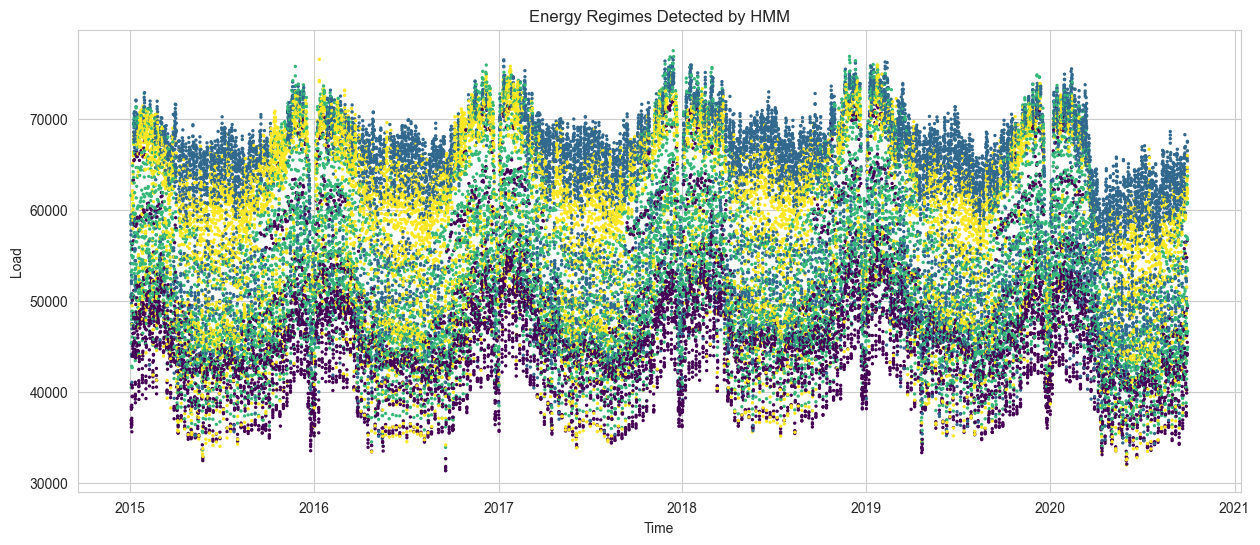

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.scatter(
    df_regimes.index,
    df_regimes["load"],
    c=df_regimes["regime"],
    cmap="viridis",
    s=2
)

plt.title("Energy Regimes Detected by HMM")
plt.xlabel("Time")
plt.ylabel("Load")

plt.show()